# Notebook 05: ARIMAX Modeling

This notebook extends the univariate ARIMA baseline by adding Brent crude oil prices and the USD/GHS exchange rate as external regressors. It compares candidate orders using AIC, forecasts the six-month holdout, checks residual autocorrelation, and calculates forecast errors. The forecast is conditional on the future external-variable values being available.

In [1]:
# ARIMAX modeling for diesel, petrol, and LPG
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/dataset_final/full_data.csv")
df["date"] = pd.to_datetime(df["month"], format="%YM%m")
df = df.set_index("date").asfreq("MS")

fuel_cols = [
    "diesel_price_(GHC/litre)",
    "petrol_price_ghs/litre",
    "lpg_ghs/kg",
]
# The project methodology treats these variables as external shocks.
external_cols = [
    "brent_price_usd_per_barrel",
    "usd/ghs_rate",
]
horizon = 6
train = df.iloc[:-horizon]
test = df.iloc[-horizon:]

print(f"Training period: {train.index.min():%Y-%m} to {train.index.max():%Y-%m}")
print(f"Test period: {test.index.min():%Y-%m} to {test.index.max():%Y-%m}")

Training period: 2015-07 to 2025-12
Test period: 2026-01 to 2026-06


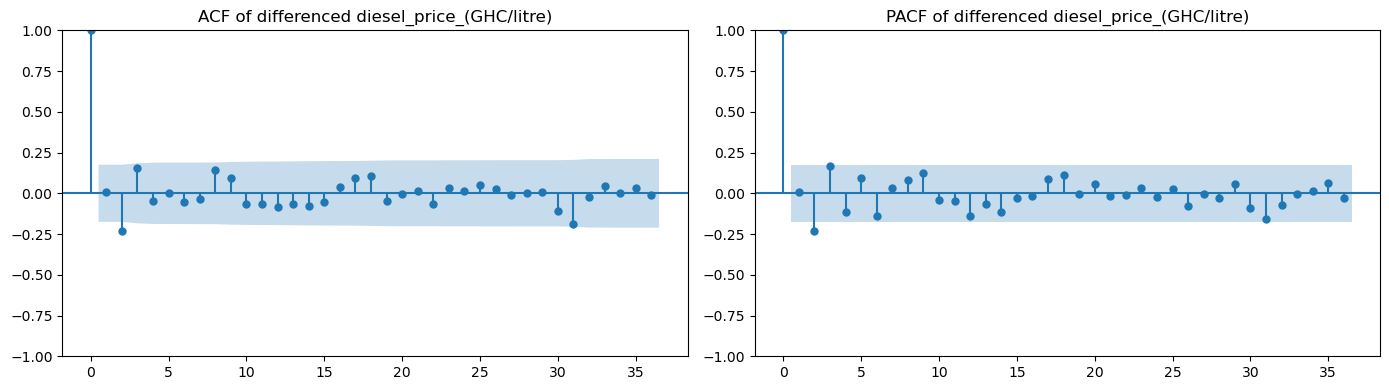

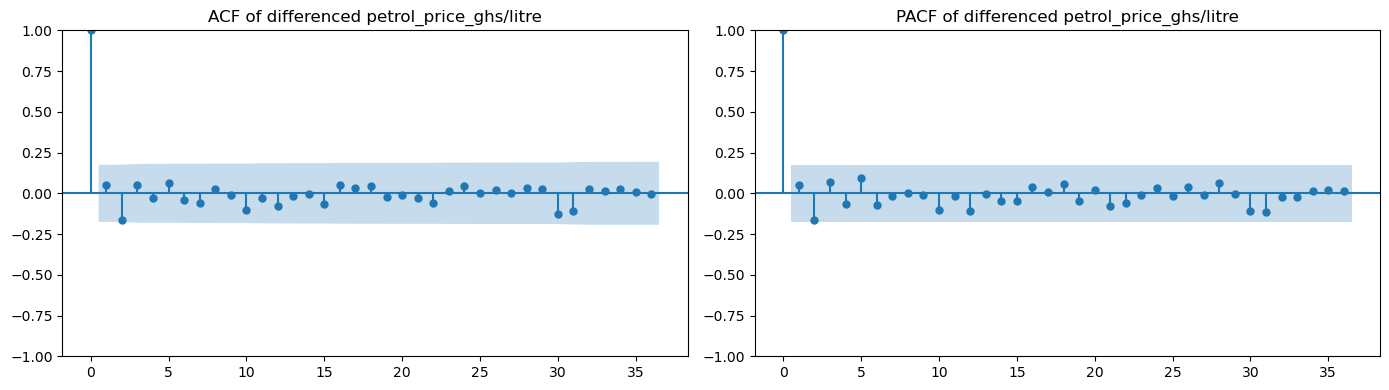

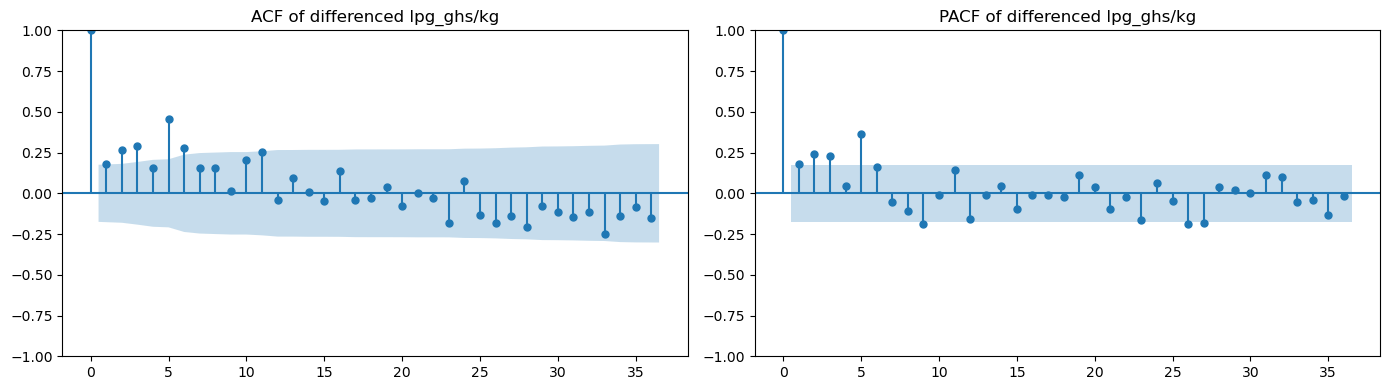

Selected ARIMAX orders from training data:
{'diesel_price_(GHC/litre)': (0, 1, 3), 'petrol_price_ghs/litre': (0, 1, 3), 'lpg_ghs/kg': (1, 1, 3)}
                      series      order         AIC         BIC
3   diesel_price_(GHC/litre)  (0, 1, 3)  244.323099  261.097843
7   diesel_price_(GHC/litre)  (1, 1, 3)  245.815738  265.386272
6   diesel_price_(GHC/litre)  (1, 1, 2)  245.863997  262.688123
10  diesel_price_(GHC/litre)  (2, 1, 2)  246.277731  265.905878
13  diesel_price_(GHC/litre)  (3, 1, 1)  246.604118  266.232265
39                lpg_ghs/kg  (1, 1, 3)    9.133045   28.703578
45                lpg_ghs/kg  (3, 1, 1)    9.346923   28.975071
38                lpg_ghs/kg  (1, 1, 2)    9.390078   26.214205
41                lpg_ghs/kg  (2, 1, 1)    9.395571   26.268677
42                lpg_ghs/kg  (2, 1, 2)    9.531007   29.159154
19    petrol_price_ghs/litre  (0, 1, 3)  325.981439  342.756182
22    petrol_price_ghs/litre  (1, 1, 2)  327.592978  344.417105
23    petrol_price_ghs/

In [3]:
# Inspect differenced targets and select each ARIMAX order using training AIC.
candidate_orders = [(p, 1, q) for p in range(4) for q in range(4)]
selected_arimax_orders = {}
selection_rows = []

for column in fuel_cols:
    differenced = train[column].diff().dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(differenced, lags=min(36, len(differenced) // 2 - 1), ax=axes[0])
    plot_pacf(
        differenced,
        lags=min(36, len(differenced) // 2 - 1),
        ax=axes[1],
        method="ywm",
    )
    axes[0].set_title(f"ACF of differenced {column}")
    axes[1].set_title(f"PACF of differenced {column}")
    plt.tight_layout()
    plt.show()

    best_order = None
    best_aic = float("inf")
    for order in candidate_orders:
        try:
            fit = ARIMA(
                train[column],
                exog=train[external_cols],
                order=order,
                enforce_stationarity=False,
            ).fit()
            selection_rows.append(
                {
                    "series": column,
                    "order": order,
                    "AIC": fit.aic,
                    "BIC": fit.bic,
                }
            )
            if fit.aic < best_aic:
                best_order, best_aic = order, fit.aic
        except (ValueError, np.linalg.LinAlgError):
            continue
    selected_arimax_orders[column] = best_order

selection_table = pd.DataFrame(selection_rows).sort_values(["series", "AIC"])
print("Selected ARIMAX orders from training data:")
print(selected_arimax_orders)
print(selection_table.groupby("series", group_keys=False).head(5))


Residual diagnostic summary: diesel_price_(GHC/litre)
    lb_stat  lb_pvalue
10  6.28391   0.790873


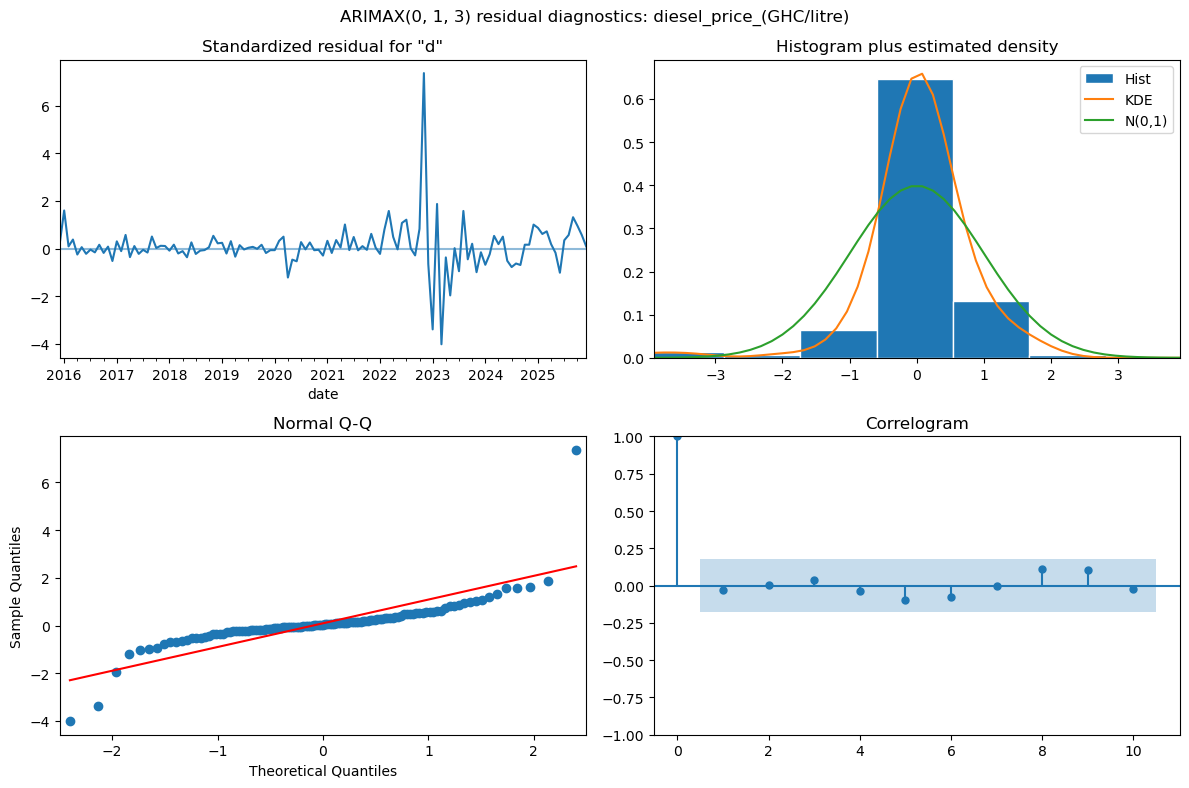


Residual diagnostic summary: petrol_price_ghs/litre
     lb_stat  lb_pvalue
10  3.647678   0.961845


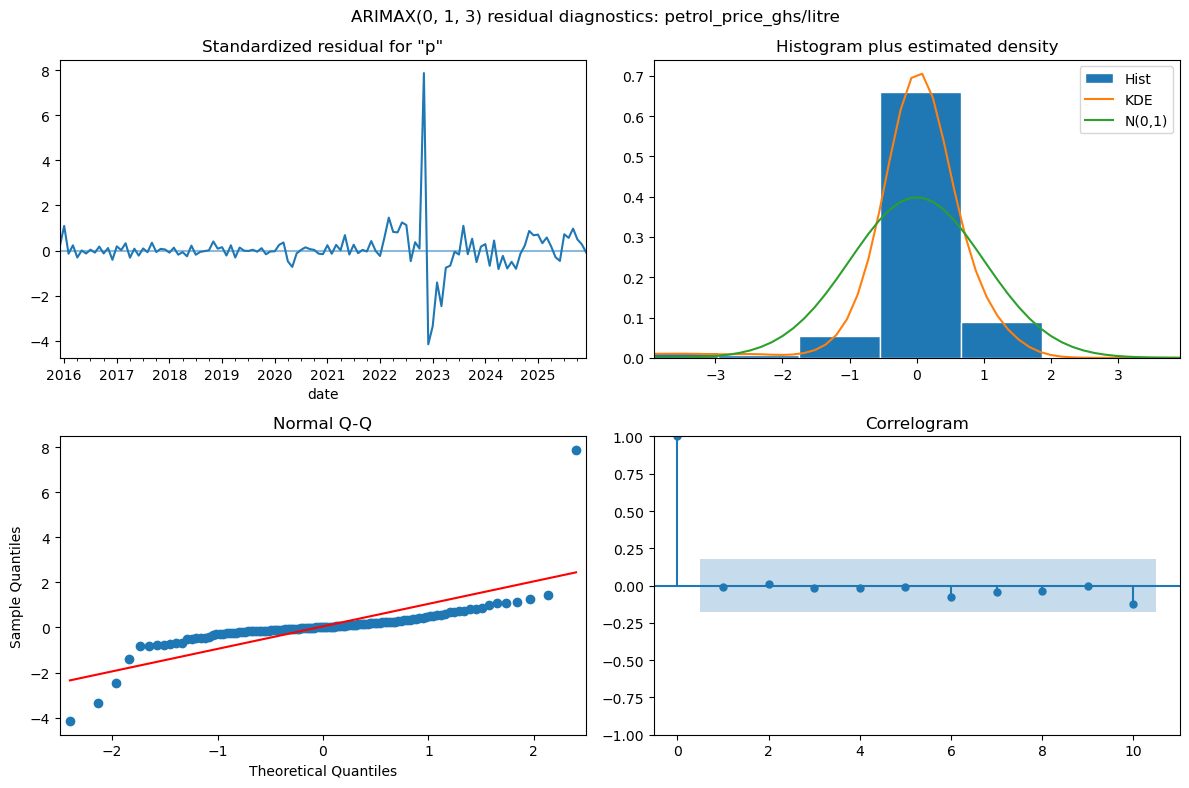


Residual diagnostic summary: lpg_ghs/kg
     lb_stat  lb_pvalue
10  9.634997   0.473078


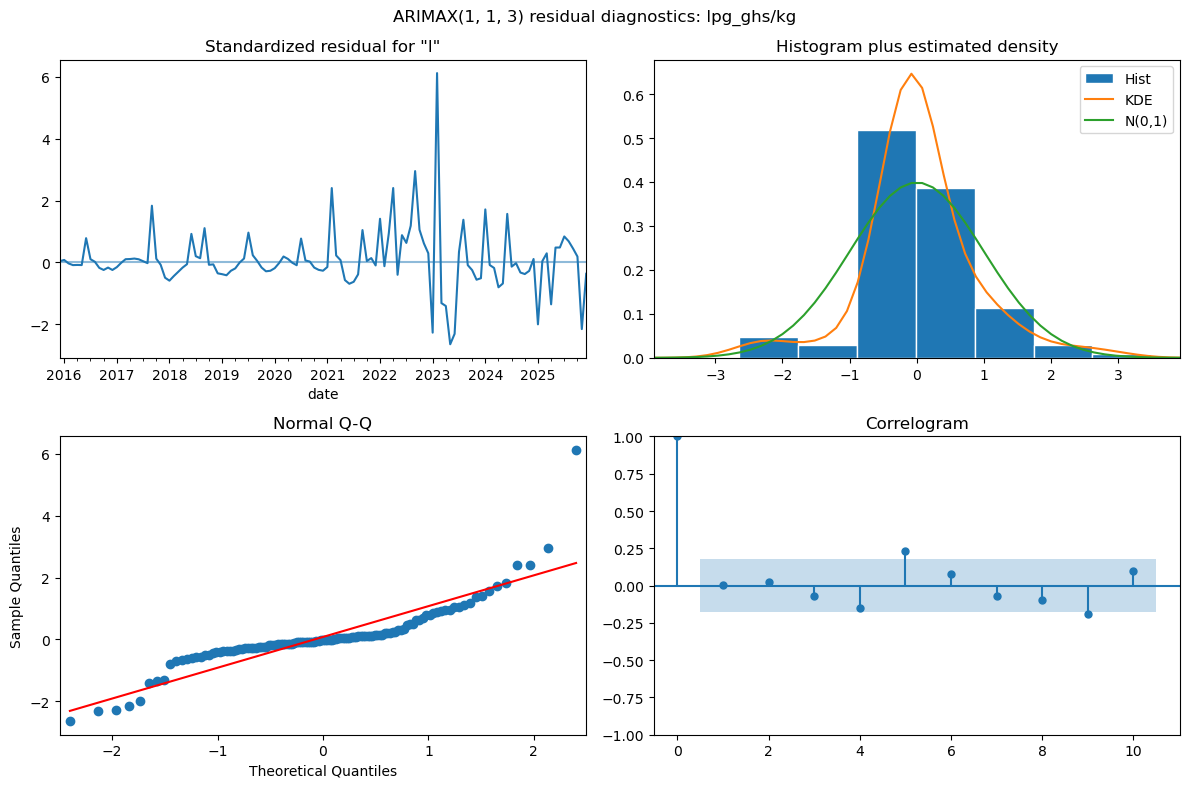


Forecast metrics:
    model                    series      order       MAE      RMSE      MAPE
0  ARIMAX  diesel_price_(GHC/litre)  (0, 1, 3)  0.476932  0.552552  3.488050
1  ARIMAX    petrol_price_ghs/litre  (0, 1, 3)  0.716239  0.780070  4.650072
2  ARIMAX                lpg_ghs/kg  (1, 1, 3)  0.113632  0.134946  0.841722

Residual diagnostics:
                     series      order  Ljung_Box_pvalue_lag10
0  diesel_price_(GHC/litre)  (0, 1, 3)                0.790873
1    petrol_price_ghs/litre  (0, 1, 3)                0.961845
2                lpg_ghs/kg  (1, 1, 3)                0.473078


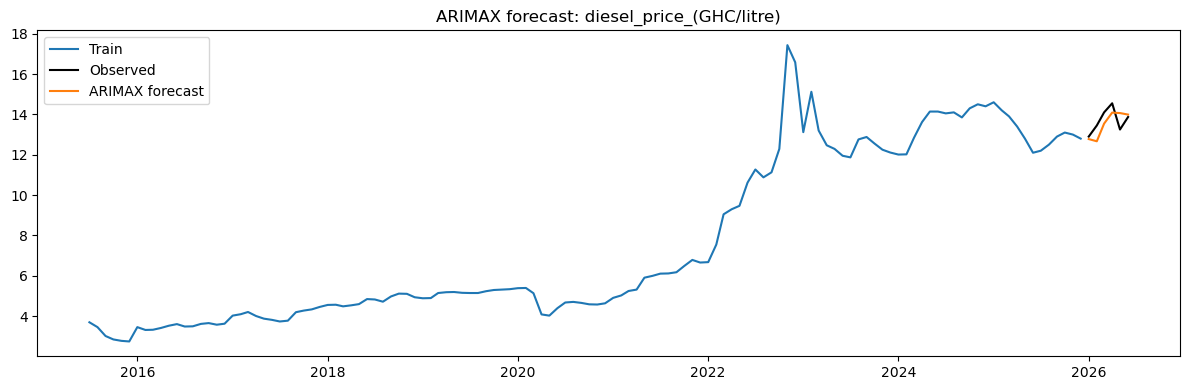

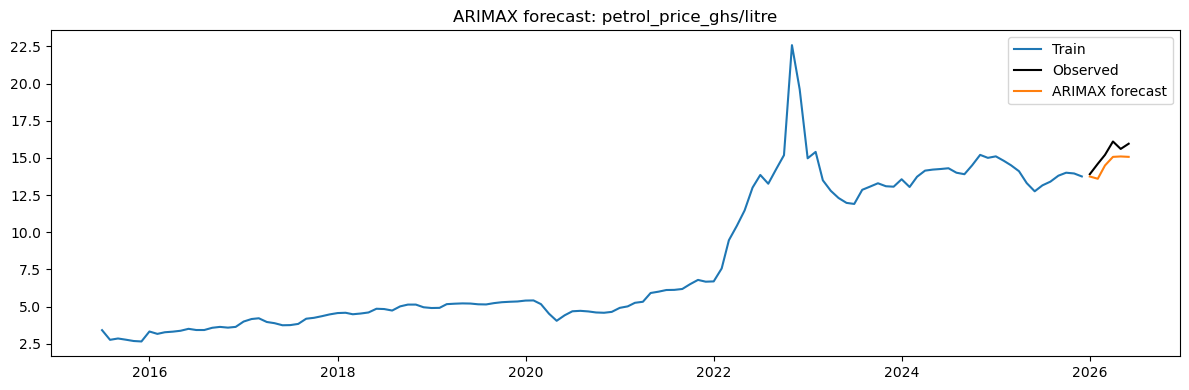

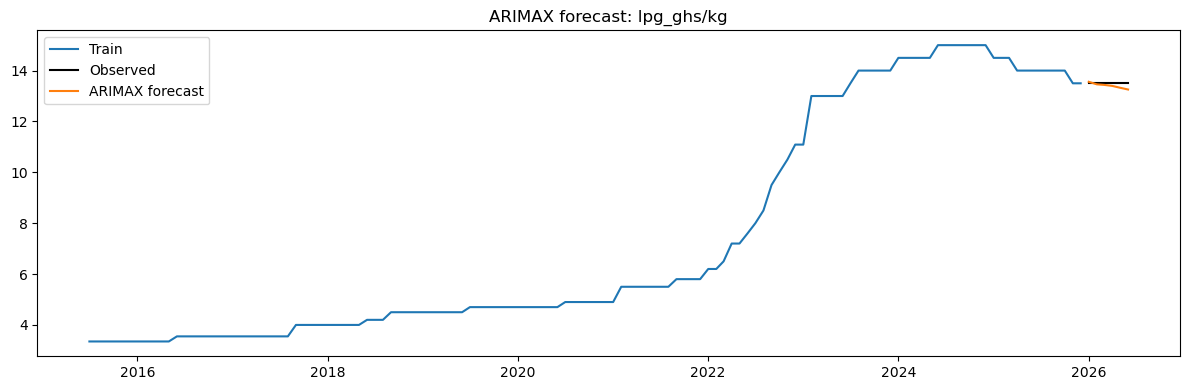

In [4]:
# Fit, diagnose, and forecast each fuel-price series with external shocks.
arimax_forecasts = pd.DataFrame(index=test.index)
arimax_metrics = []
arimax_diagnostics = []

for column, order in selected_arimax_orders.items():
    fit = ARIMA(
        train[column],
        exog=train[external_cols],
        order=order,
        enforce_stationarity=False,
    ).fit()
    forecast = fit.forecast(steps=horizon, exog=test[external_cols])
    arimax_forecasts[column] = forecast

    residuals = fit.resid.dropna()
    ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
    arimax_diagnostics.append(
        {
            "series": column,
            "order": str(order),
            "Ljung_Box_pvalue_lag10": ljung_box["lb_pvalue"].iloc[0],
        }
    )
    print(f"\nResidual diagnostic summary: {column}")
    print(ljung_box)
    fit.plot_diagnostics(figsize=(12, 8))
    plt.suptitle(f"ARIMAX{order} residual diagnostics: {column}")
    plt.tight_layout()
    plt.show()

    errors = test[column].to_numpy() - forecast.to_numpy()
    arimax_metrics.append(
        {
            "model": "ARIMAX",
            "series": column,
            "order": str(order),
            "MAE": mean_absolute_error(test[column], forecast),
            "RMSE": np.sqrt(mean_squared_error(test[column], forecast)),
            "MAPE": np.mean(np.abs(errors / test[column].to_numpy())) * 100,
        }
    )

arimax_metrics = pd.DataFrame(arimax_metrics)
arimax_diagnostics = pd.DataFrame(arimax_diagnostics)
print("\nForecast metrics:")
print(arimax_metrics)
print("\nResidual diagnostics:")
print(arimax_diagnostics)

for column in fuel_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(train.index, train[column], label="Train")
    plt.plot(test.index, test[column], label="Observed", color="black")
    plt.plot(arimax_forecasts.index, arimax_forecasts[column], label="ARIMAX forecast")
    plt.title(f"ARIMAX forecast: {column}")
    plt.legend()
    plt.tight_layout()
    plt.show()